<a href="https://colab.research.google.com/github/leozqi/resnet18_n2uq/blob/main/n2uq_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!apt-get install git-lfs
!git lfs install
!git clone https://github.com/leozqi/resnet18_n2uq.git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Git LFS initialized.
fatal: destination path 'resnet18_n2uq' already exists and is not an empty directory.


# ResNet Pruning

Load a pretrained torchvision ResNet-18 and apply structured/unstructured pruning via `torch.nn.utils.prune`.

In [8]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Load pretrained ResNet-18

In [9]:
model = models.resnet18(weights=None)
checkpoint = torch.load("resnet18_n2uq/pretrained_models/quantize_downsampling_false/resnet18-f37072fd(pytorch_model).pth", map_location="cpu")
model.load_state_dict(checkpoint)
model = model.to(device)
model.eval()

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Total conv+fc weights: {sum(p.numel() for n, p in model.named_parameters() if 'conv' in n or 'fc' in n):,}")

Total parameters: 11,689,512
Total conv+fc weights: 11,507,880


## 2. Verify baseline (random input)

In [10]:
dummy = torch.randn(1, 3, 224, 224, device=device)
with torch.no_grad():
    out = model(dummy)
print(f"Output shape: {out.shape}")
print(f"Top-5 predicted classes: {torch.topk(out, 5).indices.tolist()}")

Output shape: torch.Size([1, 1000])
Top-5 predicted classes: [[107, 611, 845, 111, 722]]


## 3. Apply unstructured (L1) pruning

Zero out the smallest-magnitude weights globally across all Conv2d and Linear layers.

In [11]:
def get_prunable_layers(module):
    """Return all Conv2d and Linear submodules."""
    layers = []
    for name, m in module.named_modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            layers.append((name, m))
    return layers

prunable = get_prunable_layers(model)
print(f"Prunable layers: {len(prunable)}")
for name, m in prunable:
    print(f"  {name}: {m}")

Prunable layers: 21
  conv1: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  layer1.0.conv1: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  layer1.0.conv2: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  layer1.1.conv1: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  layer1.1.conv2: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  layer2.0.conv1: Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  layer2.0.conv2: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  layer2.0.downsample.0: Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
  layer2.1.conv1: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  layer2.1.conv2: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  layer3.0.conv1: Conv2d(128, 2

In [12]:
SPARSITY = 0.5  # fraction of weights to zero out

parameters_to_prune = [(m, 'weight') for _, m in prunable]

prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=SPARSITY,
)

# Count nonzero weights after pruning
total = 0
nonzero = 0
for _, m in prunable:
    total += m.weight.nelement()
    nonzero += torch.count_nonzero(m.weight).item()

print(f"Global sparsity: {1 - nonzero/total:.1%}  ({nonzero:,} / {total:,} nonzero)")

Global sparsity: 50.0%  (5,839,456 / 11,678,912 nonzero)


## 4. Verify pruned model still runs

In [13]:
with torch.no_grad():
    out_pruned = model(dummy)
print(f"Output shape: {out_pruned.shape}")
print(f"Top-5 predicted classes: {torch.topk(out_pruned, 5).indices.tolist()}")

Output shape: torch.Size([1, 1000])
Top-5 predicted classes: [[489, 107, 611, 828, 5]]


## 5. Per-layer sparsity breakdown

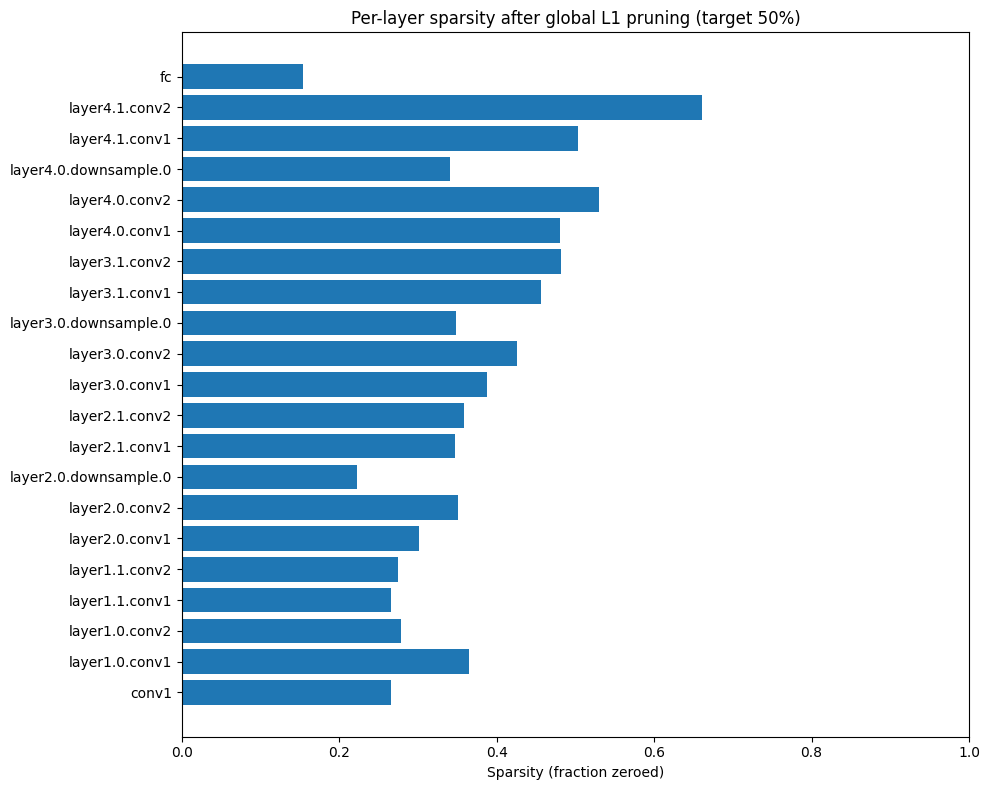

In [14]:
layer_stats = []
for name, m in prunable:
    w = m.weight
    n_total = w.nelement()
    n_zero = (w == 0).sum().item()
    layer_stats.append((name, n_total, n_zero, n_zero / n_total))

fig, ax = plt.subplots(figsize=(10, 8))
names = [s[0] for s in layer_stats]
sparsities = [s[3] for s in layer_stats]
ax.barh(names, sparsities)
ax.set_xlabel("Sparsity (fraction zeroed)")
ax.set_title(f"Per-layer sparsity after global L1 pruning (target {SPARSITY:.0%})")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 6. Make pruning permanent and save

In [15]:
# Remove pruning reparametrization so zeros become real weight values
for _, m in prunable:
    prune.remove(m, 'weight')

save_path = "resnet18_pruned_50pct.pth"
torch.save(model.state_dict(), save_path)
print(f"Saved pruned model to {save_path}")

Saved pruned model to resnet18_pruned_50pct.pth


## 7. (Optional) Structured pruning — remove entire filters

Instead of zeroing individual weights, prune entire output channels by L2 norm of the filter.

In [16]:
# Rebuild a fresh model for structured pruning demo
model_structured = models.resnet18(weights=None)
model_structured.load_state_dict(checkpoint)
model_structured = model_structured.to(device)

# Prune 30% of output channels in each conv layer
STRUCTURED_AMOUNT = 0.3

for name, m in get_prunable_layers(model_structured):
    if isinstance(m, nn.Conv2d):
        prune.ln_structured(m, name='weight', amount=STRUCTURED_AMOUNT, n=2, dim=0)

# Report: per-conv sparsity (entire zeroed-out filters)
total_structured = 0
total_channels = 0
zeroed_channels = 0
for name, m in get_prunable_layers(model_structured):
    if isinstance(m, nn.Conv2d):
        w = m.weight  # shape: (out_ch, in_ch, kH, kW)
        n_ch = w.shape[0]
        z_ch = (w.flatten(1).abs().sum(dim=1) == 0).sum().item()
        total_channels += n_ch
        zeroed_channels += z_ch
        total_structured += z_ch

print(f"Zeroed filter channels: {zeroed_channels} / {total_channels} ({zeroed_channels/total_channels:.1%})")

# Verify output shape is unchanged (filters are zeroed, not removed)
with torch.no_grad():
    out_s = model_structured(dummy)
print(f"Output shape (still same): {out_s.shape}")

Zeroed filter channels: 1440 / 4800 (30.0%)
Output shape (still same): torch.Size([1, 1000])
